# 02. Modeling

In [1]:
from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from scipy.spatial.distance import canberra, chebyshev, cityblock, correlation, cosine, euclidean
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 120)

DATA_DIR = Path('data')
MODELS_DIR = Path('models')
RESULTS_DIR = Path('results')

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
MODEL_PATH = MODELS_DIR / 'final_model.cbm'
SUBMISSION_PATH = RESULTS_DIR / 'final_submission.csv'

DTYPES = {
    'offer_depersanalised': 'str',
    'goods_depersanalised': 'str',
    'goods_category_id': 'str',
    'id': 'str',
}

RANDOM_STATE = 42
N_TITLE = 32
N_IMAGE = 64
IMG_DIM = 256
TXT_DIM = 64

In [2]:
train = pd.read_csv(TRAIN_PATH, dtype=DTYPES)
test = pd.read_csv(TEST_PATH, dtype=DTYPES)

train.head()

,offer_depersanalised,goods_depersanalised,sum_length,attrs+title_score,offer_price,goods_price,goods_category_id,target,id
0,295140,1396793,37,0.027267,1070,NaN,14.0,0,295140$1396793
1,65291,1396586,38,0.050415,698,NaN,14.0,0,65291$1396586
2,39232,1396244,38,0.087280,837,NaN,14.0,0,39232$1396244
3,39232,1396513,38,0.087280,837,NaN,14.0,0,39232$1396513
4,65052,1396237,38,0.079773,1085,NaN,14.0,0,65052$1396237


##### Объединение train/test

In [3]:
train['is_train'] = 1
test['is_train'] = 0

all_data = pd.concat([train, test], ignore_index=True, sort=False)

##### Загрузка эмбеддингов

In [4]:
def load_embedding_dict(vector_dir):
    ids = np.load(vector_dir / 'items_deperson.npy', allow_pickle=True)
    embeds = np.load(vector_dir / 'embed_deperson.npy')
    return dict(zip(ids.astype(str), embeds))

VECTOR_DIRS = {
    'offer_title': DATA_DIR / 'offer_title_vectors' / 'offer_title_vectors',
    'offer_image': DATA_DIR / 'offer_image_vectors' / 'offer_image_vectors',
    'goods_title': DATA_DIR / 'goods_title_vectors' / 'goods_title_vectors',
    'goods_image': DATA_DIR / 'goods_image_vectors' / 'goods_image_vectors',
}

embedding_dicts = {name: load_embedding_dict(path) for name, path in VECTOR_DIRS.items()}

##### Маппинг эмбеддингов на пары offer/goods

In [5]:
all_data['offer_title'] = all_data['offer_depersanalised'].astype(str).map(embedding_dicts['offer_title'])
all_data['goods_title'] = all_data['goods_depersanalised'].astype(str).map(embedding_dicts['goods_title'])
all_data['offer_image'] = all_data['offer_depersanalised'].astype(str).map(embedding_dicts['offer_image'])
all_data['goods_image'] = all_data['goods_depersanalised'].astype(str).map(embedding_dicts['goods_image'])

del embedding_dicts
gc.collect()

88

##### PCA-признаки для эмбеддингов

In [6]:
def build_pca_features(frame, column, prefix, n_components):
    mask = frame[column].notna()
    valid_vectors = np.stack(frame.loc[mask, column])

    pca = PCA(n_components=n_components)
    pca.fit(valid_vectors)

    transformed = np.full((len(frame), n_components), np.nan)
    transformed[mask] = pca.transform(valid_vectors)

    return pd.DataFrame(
        transformed,
        columns=[f'pca_{prefix}_{i}' for i in range(n_components)],
        index=frame.index,
    )

pca_feature_frames = [
    build_pca_features(all_data, 'offer_title', 'offer_title', N_TITLE),
    build_pca_features(all_data, 'goods_title', 'goods_title', N_TITLE),
    build_pca_features(all_data, 'offer_image', 'offer_image', N_IMAGE),
    build_pca_features(all_data, 'goods_image', 'goods_image', N_IMAGE),
]

all_data = all_data.join(pca_feature_frames)

added_cols = (N_TITLE * 2) + (N_IMAGE * 2)
print(f'added cols: {added_cols}')

del pca_feature_frames
gc.collect()

added cols: 192


0

##### Подготовка матриц эмбеддингов для distance-features

In [7]:
def safe_stack(series, dim):
    return np.stack([
        value if isinstance(value, np.ndarray) else np.zeros(dim)
        for value in series.values
    ])

offer_img = safe_stack(all_data['offer_image'], IMG_DIM)
goods_img = safe_stack(all_data['goods_image'], IMG_DIM)
offer_txt = safe_stack(all_data['offer_title'], TXT_DIM)
goods_txt = safe_stack(all_data['goods_title'], TXT_DIM)

##### Метрики сходства между offer и goods

In [8]:
def safe_corr(v1, v2):
    value = correlation(v1, v2)
    return 1.0 if np.isnan(value) else value


def safe_pearsonr(v1, v2):
    try:
        return pearsonr(v1, v2)[0]
    except Exception:
        return 0.0


def safe_spearmanr(v1, v2):
    try:
        return spearmanr(v1, v2)[0]
    except Exception:
        return 0.0


def add_distance_features(frame, left_vectors, right_vectors, suffix):
    frame[f'manhattan_{suffix}'] = [cityblock(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'euclidean_{suffix}'] = [euclidean(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'cosine_{suffix}'] = [cosine(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'correlation_{suffix}'] = [safe_corr(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'canberra_{suffix}'] = [canberra(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'pearson_{suffix}'] = [safe_pearsonr(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'spearman_{suffix}'] = [safe_spearmanr(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]
    frame[f'chebyshev_{suffix}'] = [chebyshev(v1, v2) for v1, v2 in zip(left_vectors, right_vectors)]


add_distance_features(all_data, offer_txt, goods_txt, 'title')
add_distance_features(all_data, offer_img, goods_img, 'image')

del offer_img, goods_img, offer_txt, goods_txt
gc.collect()

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\spatial\distance.py:685: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\spatial\distance.py:685: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)
C:\Users\pc\AppData\Local\Temp/ipykernel_13920/1066283589.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(v1, v2)[0]
C:\Users\pc\AppData\Local\Temp/ipykernel_13920/1066283589.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(v1, v2)[0]


0

In [9]:
all_data.columns

Index(['offer_depersanalised', 'goods_depersanalised', 'sum_length',
       'attrs+title_score', 'offer_price', 'goods_price', 'goods_category_id',
       'target', 'id', 'is_train',
       ...
       'spearman_title', 'chebyshev_title', 'manhattan_image',
       'euclidean_image', 'cosine_image', 'correlation_image',
       'canberra_image', 'pearson_image', 'spearman_image', 'chebyshev_image'],
      dtype='object', length=222)

##### Взаимодействия distance-features

In [10]:
DISTANCE_METRICS = [
    'cosine',
    'euclidean',
    'manhattan',
    'correlation',
    'canberra',
    'pearson',
    'spearman',
    'chebyshev',
]

for metric in DISTANCE_METRICS:
    all_data[f'{metric}_prod'] = all_data[f'{metric}_title'] * all_data[f'{metric}_image']
    all_data[f'score_{metric}_title'] = all_data['attrs+title_score'] * all_data[f'{metric}_title']
    all_data[f'score_{metric}_image'] = all_data['attrs+title_score'] * all_data[f'{metric}_image']

##### Price-features и category target encoding

In [11]:
all_data['price_diff'] = abs(all_data['offer_price'] - all_data['goods_price']).fillna(0)
all_data['price_ratio'] = all_data['offer_price'] / (all_data['goods_price'] + 1)
all_data['score_price_ratio'] = all_data['attrs+title_score'] * all_data['price_ratio']

all_data['log_offer_price'] = np.log1p(all_data['offer_price'])
all_data['log_goods_price'] = np.log1p(all_data['goods_price'])
all_data['log_price_diff'] = abs(all_data['log_offer_price'] - all_data['log_goods_price'])

all_data['score_log_price_diff'] = all_data['attrs+title_score'] * all_data['log_price_diff']
all_data['price_diff_log_ratio'] = all_data['log_price_diff'] / (
    all_data['log_offer_price'] + all_data['log_goods_price'] + 1
)

category_mean = train.groupby('goods_category_id')['target'].mean()
all_data['cat_mean_target'] = all_data['goods_category_id'].map(category_mean).fillna(train['target'].mean())

##### Бинарные и ранговые признаки

In [12]:
all_data['has_both_images'] = (
    all_data['offer_image'].notna() & all_data['goods_image'].notna()
).astype(int)
all_data['is_much_cheaper'] = (all_data['price_ratio'] < 0.75).astype(int)
all_data['is_much_more_expensive'] = (all_data['price_ratio'] > 1.40).astype(int)

all_data['price_ratio_rank_in_offer'] = all_data.groupby('offer_depersanalised')['price_ratio'].rank(
    method='min',
    ascending=True,
)
all_data['price_ratio_rank_in_offer'] = all_data['price_ratio_rank_in_offer'].fillna(1.0)
all_data['price_ratio_log'] = np.log1p(all_data['price_ratio'].clip(0.1, 10))

In [13]:
all_data.isna().sum()

offer_depersanalised              0
goods_depersanalised              0
sum_length                        0
attrs+title_score                 0
offer_price                       0
                              ...  
has_both_images                   0
is_much_cheaper                   0
is_much_more_expensive            0
price_ratio_rank_in_offer         0
price_ratio_log              466258
Length: 260, dtype: int64

##### Финальная подготовка train/test

In [14]:
all_data.drop(
    columns=[
        'offer_depersanalised',
        'goods_depersanalised',
        'offer_title',
        'goods_title',
        'offer_image',
        'goods_image',
    ],
    inplace=True,
)

gc.collect()

0

In [15]:
train = all_data[all_data['is_train'] == 1].drop(columns=['is_train'])
test = all_data[all_data['is_train'] == 0].drop(columns=['target', 'is_train'])

del all_data
gc.collect()

0

##### Обучение базовой CatBoost-модели

In [16]:
X = train.drop(columns=['target', 'id'])
y = train['target']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

model = CatBoostClassifier(
    iterations=1000,
    eval_metric='F1',
    random_state=RANDOM_STATE,
    early_stopping_rounds=100,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

val_pred = model.predict(X_val)
f1 = f1_score(y_val, val_pred)
print(f'F1 на валидации: {f1:.4f}')

Learning rate set to 0.210647
0:	learn: 0.9086009	test: 0.9079618	best: 0.9079618 (0)	total: 725ms	remaining: 12m 4s
100:	learn: 0.9217504	test: 0.9204897	best: 0.9205256 (97)	total: 36.5s	remaining: 5m 24s
200:	learn: 0.9248617	test: 0.9217853	best: 0.9218714 (189)	total: 1m 10s	remaining: 4m 39s
300:	learn: 0.9273457	test: 0.9228437	best: 0.9228725 (278)	total: 1m 43s	remaining: 4m 1s
400:	learn: 0.9294032	test: 0.9235013	best: 0.9237347 (373)	total: 2m 17s	remaining: 3m 24s
500:	learn: 0.9313776	test: 0.9241884	best: 0.9242173 (498)	total: 2m 50s	remaining: 2m 49s
600:	learn: 0.9332584	test: 0.9244176	best: 0.9245430 (592)	total: 3m 24s	remaining: 2m 15s
700:	learn: 0.9348074	test: 0.9247362	best: 0.9247565 (698)	total: 3m 58s	remaining: 1m 41s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9247565069
bestIteration = 698

Shrink model to first 699 iterations.
F1 на валидации: 0.9248


In [17]:
del X, y
gc.collect()

0

##### Pseudo-labeling

In [18]:
test_proba = model.predict_proba(test[X_train.columns])[:, 1]

high_threshold = 0.99
low_threshold = 0.01

confident_pos_mask = test_proba > high_threshold
confident_neg_mask = test_proba < low_threshold
confident_mask = confident_pos_mask | confident_neg_mask

print(f'Уверенных positive: {confident_pos_mask.sum()} ({confident_pos_mask.mean():.2%})')
print(f'Уверенных negative: {confident_neg_mask.sum()} ({confident_neg_mask.mean():.2%})')

pseudo_data = test[confident_mask].copy()
pseudo_data['target'] = 0
pseudo_data.loc[confident_pos_mask[confident_mask], 'target'] = 1
pseudo_data['weight'] = 0.5

extended_train = pd.concat([train.copy(), pseudo_data], ignore_index=True)
extended_X = extended_train.drop(['target', 'id', 'weight'], axis=1, errors='ignore')
extended_y = extended_train['target']
extended_weights = extended_train['weight'].fillna(1.0)

Уверенных positive: 2671 (0.73%)
Уверенных negative: 302949 (83.27%)


##### Дообучение на расширенной выборке

In [19]:
model.fit(
    extended_X,
    extended_y,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

del extended_weights, test_proba, confident_pos_mask, confident_neg_mask, confident_mask
gc.collect()

Learning rate set to 0.225567
0:	learn: 0.9119029	test: 0.9106500	best: 0.9106500 (0)	total: 724ms	remaining: 12m 3s
100:	learn: 0.9226158	test: 0.9217136	best: 0.9217136 (100)	total: 56.5s	remaining: 8m 22s
200:	learn: 0.9258360	test: 0.9249668	best: 0.9249668 (200)	total: 1m 40s	remaining: 6m 39s
300:	learn: 0.9281787	test: 0.9276351	best: 0.9278103 (294)	total: 2m 25s	remaining: 5m 38s
400:	learn: 0.9301706	test: 0.9295124	best: 0.9295226 (399)	total: 3m 8s	remaining: 4m 42s
500:	learn: 0.9319427	test: 0.9311696	best: 0.9311738 (497)	total: 3m 52s	remaining: 3m 51s
600:	learn: 0.9335649	test: 0.9328590	best: 0.9328590 (600)	total: 4m 36s	remaining: 3m 3s
700:	learn: 0.9351961	test: 0.9342768	best: 0.9343091 (698)	total: 5m 20s	remaining: 2m 16s
800:	learn: 0.9366938	test: 0.9358559	best: 0.9358690 (798)	total: 6m 3s	remaining: 1m 30s
900:	learn: 0.9382510	test: 0.9373917	best: 0.9374096 (898)	total: 6m 47s	remaining: 44.8s
999:	learn: 0.9396047	test: 0.9387895	best: 0.9388612 (987)	

0

##### Сохранение модели

In [20]:
MODELS_DIR.mkdir(exist_ok=True)
model.save_model(str(MODEL_PATH))

##### Подбор порога

In [21]:
val_proba_final = model.predict_proba(X_val)[:, 1]


def find_best_threshold(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]


best_threshold = find_best_threshold(y_val, val_proba_final)
print('best threshold:', best_threshold)

best threshold: 0.5261477893535181


##### Формирование submission

In [22]:
test_proba_final = model.predict_proba(test[model.feature_names_])[:, 1]
test_pred = (test_proba_final >= 0.41).astype(int)

submission = pd.DataFrame({
    'id': test['id'],
    'target': test_pred,
})

RESULTS_DIR.mkdir(exist_ok=True)
submission.to_csv(SUBMISSION_PATH, index=False)

##### Важность признаков

Топ важных признаков:


,Feature Id,Importances
0,pca_goods_image_1,12.868208
1,sum_length,12.070760
2,score_price_ratio,5.998302
3,attrs+title_score,5.881674
4,cat_mean_target,4.141954
5,pca_goods_image_19,4.014322
6,score_manhattan_title,3.859048
7,score_canberra_title,3.124405
8,pca_goods_image_55,2.816783
9,pca_goods_image_25,2.452549


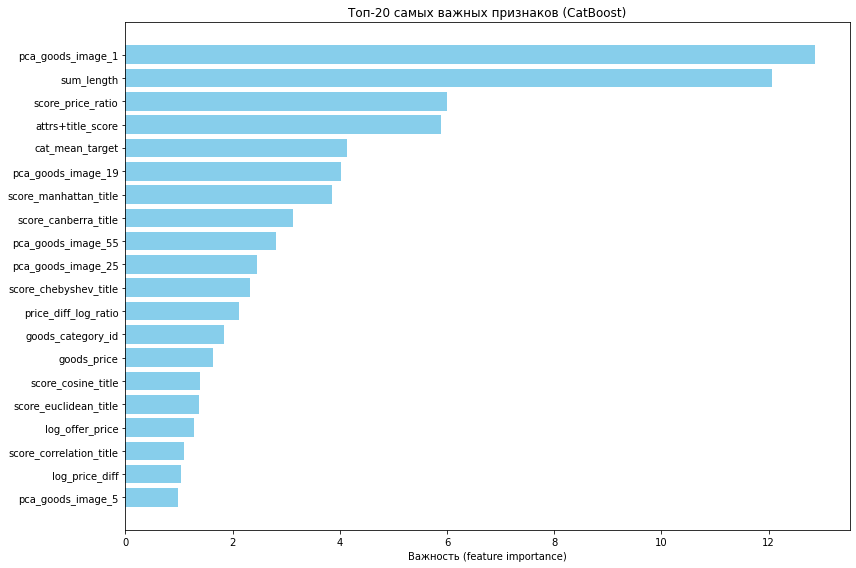

In [23]:
importances = model.get_feature_importance(prettified=True)

print('Топ важных признаков:')
display(importances.head(50))

plt.figure(figsize=(12, 8))
plt.barh(
    importances['Feature Id'][:20][::-1],
    importances['Importances'][:20][::-1],
    color='skyblue',
)
plt.xlabel('Важность (feature importance)')
plt.title('Топ-20 самых важных признаков (CatBoost)')
plt.tight_layout()
plt.show()